# 6회차 | 회귀

**핵심 질문**: "얼마나"를 예측하는 문제는 어떻게 푸는가?

**오늘의 목표**
1. **분류 vs 회귀**: 경계선 vs 추세선
2. **y = ax + b**: 기울기/절편의 물리적 의미
3. **잔차와 Loss**: RSS를 최소화하는 직선 = OLS
4. **다중회귀**: β계수 해석, 다중공선성(VIF)
5. **모델 평가**: R², MAE, RMSE + 잔차 산점도/QQ-Plot
6. **규제**: Ridge(L2) vs Lasso(L1) — 과적합 억제
7. **다항회귀**: PolynomialFeatures로 곡선 표현
8. **경사하강법**: Loss 표면을 따라 내려가는 학습 원리

**예제**: 합성 데이터 (OLS/잔차 시각화), Advertising 데이터 (다중회귀, β계수, VIF)

---
## 복습 → 회귀로의 전환

세 가지 분류 방식을 배움:

| 알고리즘 | 핵심 아이디어 | 예측 대상 | 회차 |
|---------|-------------|----------|:-----:|
| **로지스틱 회귀** | 점수 → 확률 → 분류 | 범주 (0/1) | 4-1 |
| **KNN** | 가까운 이웃끼리 다수결 | 범주 (0/1) | 4-2 |
| **결정 트리** | 질문을 반복해서 분류 | 범주 (0/1) | 5-1 |
| **회귀** | 추세선으로 숫자 예측 | **연속값 (실수)** | **오늘!** |

> 지금까지: "이것은 A인가 B인가?" → **분류(Classification)**  
> **오늘부터: "이것은 얼마인가?"** → **회귀(Regression)**

### 분류와 회귀의 핵심 차이

- **분류**: 경계선(Decision Boundary)을 그어 **라벨**을 나눔
- **회귀**: 추세선(Trend Line)을 그어 **숫자**를 예측

> **"경계선 대신 추세선, 라벨 대신 숫자"**

## 회귀

회귀(Regression)는 데이터를 통해 관계의 크기(얼마나)를 수량적으로 설명하고 예측하는 방법
- 분류(Classification): 경계선을 그려 **라벨**을 나눔 (고양이/개)
- 회귀(Regression): 추세선을 그려 **숫자**를 예측 (점수/가격/매출)

### 목표
- 회귀가 무엇인지, 왜 필요한지 **직관**으로 이해
- **y = ax + b** (기울기/절편)의 의미 파악
- 분류 vs 회귀 비교

## 회귀의 철학
- 세상에는 '얼마나(How much)'를 묻는 문제도 많음
  - 공부시간 ↑ → 점수는 얼마나 변할까?
  - 광고비 ↑ → 매출은 얼마나 늘까?
  - 온도 ↑ → 아이스크림 판매량은 얼마나 늘까?
- 회귀는 이런 연속값(Continuous)을 예측하는 방법

핵심
> 회귀는 “데이터의 관계를 **수량화**해 **예측**하는 방법”

## 분류 vs 회귀 — 경계선 vs 추세선
- **분류(Classification)**: 범주 라벨(0/1/2…)을 예측 → **경계선(Decision Boundary)**
- **회귀(Regression)**: 연속값을 예측 → **추세선(Trend Line)**

In [1]:
import numpy as np
import plotly.graph_objects as go
np.random.seed(42)

x_class = np.linspace(0, 10, 30)
y_class = (x_class + np.random.randn(30)*2 > 5).astype(int)

x_reg = np.linspace(0, 10, 30)
y_reg = 2.3 * x_reg + 4 + np.random.randn(30)*3

fig = go.Figure()

fig.add_trace(go.Scatter(x=x_class, y=y_class, mode="markers",
                         name="Classification (범주)", marker=dict(color="orange", size=9, opacity=0.8)))
fig.add_trace(go.Scatter(x=[5,5], y=[-0.5,1.5], mode="lines",
                         name="Decision Boundary", line=dict(color="orange", dash="dot")))

fig.add_trace(go.Scatter(x=x_reg, y=y_reg, mode="markers",
                         name="Regression (연속값)", marker=dict(color="cyan", size=9, opacity=0.8)))
fig.add_trace(go.Scatter(x=x_reg, 
                         y=2.3*x_reg + 4,
                         mode="lines",
                         name="Trend Line", line=dict(color="cyan", width=3)))

fig.update_layout(title="Classification vs Regression — 경계선 vs 추세선",
                  xaxis_title="X", yaxis_title="Y", template="plotly_dark",
                  legend_title="개념 비교")
fig.show()

##  직선의 언어: y = ax + b
- **a (slope, 기울기)**: X가 1 증가할 때 Y의 평균 변화량 (변화율)
- **b (intercept, 절편)**: X=0일 때의 Y 값 (출발점)

예: y = 2.5x + 5
- “X가 1 늘면 Y는 **2.5** 증가”
- “X=0일 때 Y는 **5**.”

In [2]:
import numpy as np
import plotly.graph_objects as go

x = np.linspace(0, 10, 200)
fig = go.Figure()

for slope, intercept, color in [(0.5, 2, "gray"), (2.0, 1.0, "cyan"), (4.0, 0.0, "magenta")]:
    y = slope * x + intercept
    fig.add_trace(go.Scatter(x=x, y=y, mode="lines",
                             name=f"Slope={slope}, Intercept={intercept}",
                             line=dict(color=color, width=3)))
fig.update_layout(title="기울기(slope)와 절편(intercept)의 의미",
                  xaxis_title="X", yaxis_title="Y", template="plotly_dark")
fig.show()

## 왜 '직선'?
- 직선은 가장 **단순**하고 **해석이 쉬움**
- 계산이 **빠르고 안정적**
- **비선형**(곡선)도, 변수를 변환해(Polynomial 등) **선형 모델로 표현** 가능
- 대부분의 ML은 선형 모델의 아이디어에서 확장 (규제, 경사하강법, 로지스틱 등)

# 잔차(Residual)와 Loss 개념
회귀선이 데이터를 "잘 맞춘다"는 말의 수학적 의미를 잔차와 Loss로 정의
- 잔차 Residual = 실제값 − 예측값
- Loss = 잔차 제곱합(RSS)
- RSS를 가장 작게 만드는 β₀·β₁ 조합 → 최적 직선(OLS)
  - **β₀ = y절편 (Intercept)**: X=0일 때의 Y값 (직선의 출발점)
  - **β₁ = 기울기 (Slope)**: X가 1 증가할 때 Y의 평균 변화량

## 직선이 데이터를 잘 맞춘다는 뜻
> 예측값 ŷ과 실제값 y 차이가 작을수록 모델 적합도가 높음

In [3]:
import numpy as np, plotly.graph_objects as go

np.random.seed(42)
x = np.linspace(0, 10, 10)
y = 2.3 * x + 4 + np.random.randn(10) * 3
y_pred = 2.3 * x + 4

fig = go.Figure()
fig.add_trace(go.Scatter(x=x, y=y, mode="markers",
                         name="실제 데이터", marker=dict(color="cyan", size=10)))
fig.add_trace(go.Scatter(x=x, y=y_pred, mode="lines",
                         name="예측선", line=dict(color="yellow", width=3)))

for xi, yi, ypi in zip(x, y, y_pred):
    fig.add_trace(go.Scatter(x=[xi, xi], y=[yi, ypi],
                             mode="lines", line=dict(color="magenta", dash="dot"),
                             showlegend=False))
fig.update_layout(title="잔차(Residual) 시각화 — 각 점에서 직선까지의 거리",
                  xaxis_title="X", yaxis_title="Y", template="plotly_dark")
fig.show()

## Loss(손실) 개념 — 왜 제곱?
- 부호 제거 (+/− 상쇄 방지)
- 큰 오차에 큰 벌점 부여
- 미분 가능 → 최적화 용이

![The Default Choice: 왜 회귀의 기본은 MSE인가?](스크린샷%202026-02-21%20오후%208.54.41.png)

![수학적 우아함: 미분 가능성과 볼록성](스크린샷%202026-02-21%20오후%208.54.55.png)

![통계적 가정: 정규분포에 대한 믿음](스크린샷%202026-02-21%20오후%208.55.12.png)

### MSE vs MAE vs Huber — 손실함수 비교

| 손실함수 | 수식 | gradient | 특징 |
|---------|------|----------|------|
| **MSE** | e² | 2e (오차에 비례) | 부드러운 U자, 이상치에 민감, 경사하강법 안정적 |
| **MAE** | \|e\| | +1 또는 -1 (항상 일정) | 뾰족한 V자, 이상치에 강함, 0에서 미분 불가능 |
| **Huber** | 작은 오차→e², 큰 오차→\|e\| | MSE+MAE 혼합 | 이상치 부분 완화, 분포 확신 없을 때 |

> **MSE가 회귀 기본 손실함수인 이유:**
> 1. 모든 지점에서 미분 가능 (경사하강법 안정적)
> 2. 오차가 정규분포라는 통계적 가정 → MLE와 동일
> 3. 볼록(convex) → 전역 최소값 하나 보장

In [4]:
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

e = np.linspace(-5, 5, 200)

mse_loss = e**2
mae_loss = np.abs(e)
delta = 1.5
huber_loss = np.where(np.abs(e) <= delta, 0.5 * e**2, delta * (np.abs(e) - 0.5 * delta))

mse_grad = 2 * e
mae_grad = np.sign(e)
huber_grad = np.where(np.abs(e) <= delta, e, delta * np.sign(e))

fig = make_subplots(rows=1, cols=2, subplot_titles=["손실함수 (Loss)", "기울기 (Gradient)"])

fig.add_trace(go.Scatter(x=e, y=mse_loss, name="MSE (e²)", line=dict(color="cyan", width=2)), row=1, col=1)
fig.add_trace(go.Scatter(x=e, y=mae_loss, name="MAE (|e|)", line=dict(color="orange", width=2)), row=1, col=1)
fig.add_trace(go.Scatter(x=e, y=huber_loss, name=f"Huber (δ={delta})", line=dict(color="magenta", width=2)), row=1, col=1)

fig.add_trace(go.Scatter(x=e, y=mse_grad, name="MSE grad (2e)", line=dict(color="cyan", width=2, dash="dash"), showlegend=False), row=1, col=2)
fig.add_trace(go.Scatter(x=e, y=mae_grad, name="MAE grad (±1)", line=dict(color="orange", width=2, dash="dash"), showlegend=False), row=1, col=2)
fig.add_trace(go.Scatter(x=e, y=huber_grad, name="Huber grad", line=dict(color="magenta", width=2, dash="dash"), showlegend=False), row=1, col=2)

fig.update_layout(
    title="MSE vs MAE vs Huber — 손실함수와 Gradient 비교",
    template="plotly_dark", width=900, height=400,
    legend=dict(x=0.01, y=0.99, bgcolor="rgba(0,0,0,0)")
)
fig.update_xaxes(title_text="오차 (e)", row=1, col=1)
fig.update_xaxes(title_text="오차 (e)", row=1, col=2)
fig.update_yaxes(title_text="Loss", row=1, col=1)
fig.update_yaxes(title_text="Gradient", row=1, col=2)
fig.show()

print("MSE: 오차가 클수록 기울기도 커짐 → 큰 오차에 민감 (이상치에 약함)")
print("MAE: 오차 크기 상관없이 기울기 = ±1 → 이상치에 강하지만 0에서 꺾임")
print("Huber: 작은 오차는 MSE처럼 부드럽게, 큰 오차는 MAE처럼 완만하게")

MSE: 오차가 클수록 기울기도 커짐 → 큰 오차에 민감 (이상치에 약함)
MAE: 오차 크기 상관없이 기울기 = ±1 → 이상치에 강하지만 0에서 꺾임
Huber: 작은 오차는 MSE처럼 부드럽게, 큰 오차는 MAE처럼 완만하게


![MAE(Mean Absolute Error)의 강직함](스크린샷%202026-02-21%20오후%208.55.52.png)

![MAE의 한계: 0에서 미분 불가능](스크린샷%202026-02-21%20오후%208.56.07.png)

![Huber Loss: 두 세계의 공존](스크린샷%202026-02-21%20오후%208.56.25.png)

![언제 Huber Loss를 선택해야 하는가?](스크린샷%202026-02-21%20오후%208.56.38.png)

## RSS Surface 시각화 — "가장 작은 오차의 직선"
β₀·β₁을 변화시키며 RSS(잔차 제곱합) 크기 시각화

In [5]:
x = np.linspace(0, 10, 20)
y = 2.3*x + 4 + np.random.randn(20)*3

def rss(b0, b1):
    y_pred = b0 + b1*x
    return np.sum((y - y_pred)**2)

b0_range, b1_range = np.linspace(0,8,50), np.linspace(0,4,50)
B0, B1 = np.meshgrid(b0_range, b1_range)
RSS = np.array([[rss(b0, b1) for b0 in b0_range] for b1 in b1_range])

fig = go.Figure(data=[go.Surface(z=RSS, x=b0_range, y=b1_range, colorscale="Viridis")])
fig.update_layout(title="RSS Surface — β₀·β₁ 조합별 손실",
                  scene=dict(xaxis_title="β₀", yaxis_title="β₁", zaxis_title="RSS"),
                  template="plotly_dark")
fig.show()

## 최소제곱법(OLS)의 철학
> "가장 좋은 직선" = 모든 데이터의 잔차 제곱합(RSS)을 가장 작게 만드는 직선

OLS는 모든 점의 오차를 가장 공평하게 분산시키는 직선을 찾는 방법.

## 요약
- 잔차 = 실제 − 예측 → 오차의 단위
- Loss = 잔차 제곱합(RSS)
- 최적 직선 = RSS 최소 (OLS)

## **OLS의 철학 — “가장 공평한 직선”**

|**용어**|**의미**|
|---|---|
|**Ordinary**|특별한 가정 없이 가장 단순한 방법|
|**Least Squares**|잔차의 제곱합을 최소화하는 원리|


### 핵심

> “OLS는 모든 데이터 포인트의 오차를 **가장 공평하게 분산시키는 직선**을 찾는 방법”

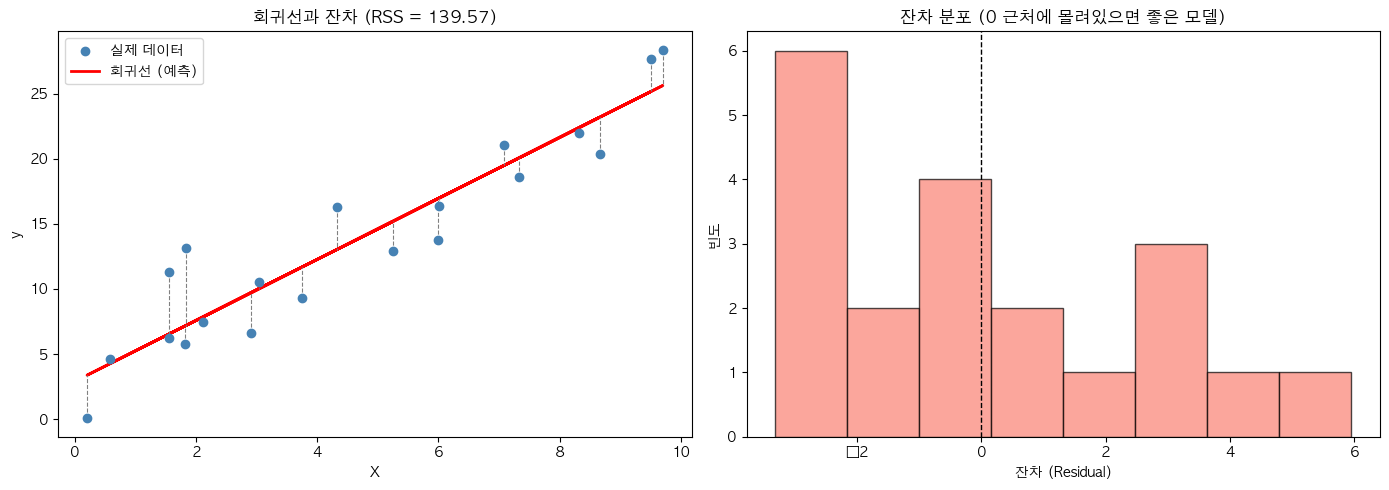

In [38]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import platform

# OS에 따라 다른 폰트 지정
if platform.system() == 'Darwin':   # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
elif platform.system() == 'Windows':  # Windows
    plt.rcParams['font.family'] = 'Malgun Gothic'
else:  # Linux (예: Colab, Ubuntu)
    plt.rcParams['font.family'] = 'NanumGothic'

# 샘플 데이터 생성
np.random.seed(42)
X = np.random.rand(20, 1) * 10
y = 2.5 * X.flatten() + 3 + np.random.randn(20) * 3

# 회귀 모델 학습
model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)
residuals = y - y_pred
RSS = np.sum(residuals ** 2)

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# [왼쪽] 회귀선 + 잔차(점선)
axes[0].scatter(X, y, color='steelblue', label='실제 데이터', zorder=3)
axes[0].plot(X, y_pred, color='red', linewidth=2, label='회귀선 (예측)')
for i in range(len(X)):
    axes[0].plot([X[i], X[i]], [y[i], y_pred[i]],
                 color='gray', linestyle='--', linewidth=0.8)
axes[0].set_title(f'회귀선과 잔차 (RSS = {RSS:.2f})')
axes[0].set_xlabel('X')
axes[0].set_ylabel('y')
axes[0].legend()

# [오른쪽] 잔차 분포 (히스토그램)
axes[1].hist(residuals, bins=8, color='salmon', edgecolor='black', alpha=0.7)
axes[1].axvline(0, color='black', linestyle='--', linewidth=1)
axes[1].set_title('잔차 분포 (0 근처에 몰려있으면 좋은 모델)')
axes[1].set_xlabel('잔차 (Residual)')
axes[1].set_ylabel('빈도')

plt.tight_layout()
plt.show()

## **β₀·β₁의 변화에 따른 회귀선 변화**

> β₀은 선의 ‘위치’, β₁은 선의 ‘기울기’를 결정한다.

In [6]:
import numpy as np, plotly.graph_objects as go
x = np.linspace(0, 10, 100)
fig = go.Figure()
for b1, b0, c in [(1.5, 2, "cyan"), (2.3, 4, "yellow"), (3.5, 1, "magenta")]:
    fig.add_trace(go.Scatter(x=x, y=b1*x+b0, mode="lines", name=f"β₁={b1}, β₀={b0}", line=dict(width=3, color=c)))
fig.update_layout(title="β₀, β₁에 따른 회귀선 변화", xaxis_title="X", yaxis_title="Y", template="plotly_dark")
fig.show()

## **RSS를 β₀·β₁의 함수로 보기**

> β₀(절편)과 β₁(기울기)에 따라 RSS가 어떻게 달라지는지 직접 시각화해서 확인

In [7]:
import numpy as np, plotly.graph_objects as go
np.random.seed(42)
x = np.linspace(0, 10, 20)
y = 2.3*x + 4 + np.random.randn(20)*3

def rss(b0, b1):
    y_pred = b0 + b1*x
    return np.sum((y - y_pred)**2)

b0_range = np.linspace(0, 8, 50)
b1_range = np.linspace(0, 4, 50)
B0, B1 = np.meshgrid(b0_range, b1_range)
RSS = np.array([[rss(b0, b1) for b0 in b0_range] for b1 in b1_range])

fig = go.Figure(data=[go.Surface(z=RSS, x=b0_range, y=b1_range, colorscale="Viridis")])
fig.update_layout(
    title="RSS Surface — β₀·β₁ 조합별 손실(Loss)",
    scene=dict(xaxis_title="β₀ (Intercept)", yaxis_title="β₁ (Slope)", zaxis_title="RSS"),
    template="plotly_dark")
fig.show()

## **RSS 최소점(최적 β) 탐색 — Contour 시각화**

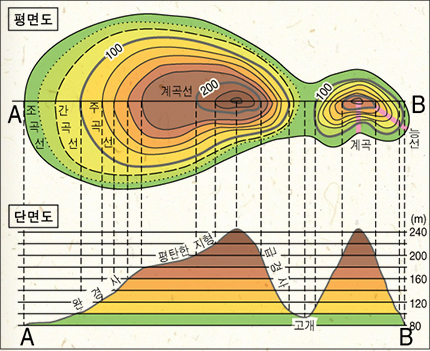

In [8]:
import numpy as np
import plotly.graph_objects as go

Z = np.log1p(RSS)

min_idx = np.unravel_index(np.argmin(Z), Z.shape)
b0_star = b0_range[min_idx[1]]
b1_star = b1_range[min_idx[0]]
z_star  = Z[min_idx]

fig = go.Figure()

fig.add_trace(go.Heatmap(
    z=Z,
    x=b0_range,
    y=b1_range,
    colorscale="Viridis",
    colorbar=dict(title="log(1 + RSS)"),
    hovertemplate=(
        "β₀ (Intercept) = %{x:.3f}<br>"
        "β₁ (Slope) = %{y:.3f}<br>"
        "log(1+RSS) = %{z:.3f}<extra></extra>"
    )
))

fig.add_trace(go.Contour(
    z=Z,
    x=b0_range,
    y=b1_range,
    showscale=False,
    contours=dict(
        coloring="none", showlabels=False, start=Z.min(),
        end=Z.max(), size=(Z.max()-Z.min())/12
    ),
    line=dict(color="rgba(255,255,255,0.35)", width=1)
))

fig.add_trace(go.Scatter(
    x=[b0_star], y=[b1_star],
    mode="markers+text",
    marker=dict(symbol="star", size=18, color="yellow", line=dict(color="black", width=1)),
    text=[f"  최소점 β₀={b0_star:.2f}, β₁={b1_star:.2f}"],
    textfont=dict(color="white"),
    name="RSS Minimum",
))

fig.update_layout(
    title="RSS Contour Map — β₀·β₁ 조합별 Loss (어두울수록 작음)",
    template="plotly_dark",
    xaxis_title="β₀ (Intercept)",
    yaxis_title="β₁ (Slope)",
    annotations=[
        dict(
            x=b0_star, y=b1_star, text="★ 최소 손실점 (RSS 최소)",
            showarrow=True, arrowhead=2, ax=60, ay=-60,
            bgcolor="rgba(255,255,0,0.2)", font=dict(color="white")
        )
    ],
    margin=dict(l=60, r=40, t=70, b=50)
)

fig.show()

print(f"RSS 최소점: β₀*={b0_star:.4f}, β₁*={b1_star:.4f}, log(1+RSS)={z_star:.4f}")

RSS 최소점: β₀*=6.3673, β₁*=1.7143, log(1+RSS)=4.5989


| **구성 요소**     | **의미**        | **해석**                             |
| ------------- | ------------- | ---------------------------------- |
| **가로축 (β₀)**  | 절편(Intercept) | 직선의 위치를 위아래로 이동                    |
| **세로축 (β₁)**  | 기울기(Slope)    | 직선의 기울기를 바꿔 데이터에 맞춤                |
| **색상(Color)** | RSS(손실 크기)    | 어두울수록 작음 → 모델이 잘 맞는 구간             |
| **별표 마커(★)**  | RSS 최소점       | 가장 작은 Loss → 최적의 β₀, β₁ 조합 (OLS 해) |


## **Gradient(기울기)와 OLS*

> “이 골짜기(최소점)를 향해 β를 조금씩 이동시키는 과정이 바로 **경사하강법(Gradient Descent)**”

## 요약
- OLS = RSS를 최소화하는 β₀·β₁ 찾기
- RSS Surface는 Convex 형태 → 항상 하나의 최소점 존재
- 최적 β는 RSS 최소점 (Loss Minimum)
- Gradient Descent = Loss Surface 내리막길 이동 과정

## 정리
- OLS는 이 골짜기 바닥 좌표를 계산하는 방법
- Gradient Descent는 그 방향으로 걸어 내려가는 방법

# 데이터 전처리 실습(예시)
- 예시임. 정말 그냥 예시

## 1. 결측치


## 예시

| **방법** | **설명**          | **sklearn 예시**                          |
| ------ | --------------- | --------------------------------------- |
| 평균 대체  | 수치형 컬럼의 평균으로 채움 | SimpleImputer(strategy='mean')          |
| 중앙값 대체 | 극단값이 있을 때 안정적   | SimpleImputer(strategy='median')        |
| 최빈값 대체 | 범주형 데이터에 사용     | SimpleImputer(strategy='most_frequent') |


## 분포에 따라서 판단하셔야 함.

In [9]:
from sklearn.impute import SimpleImputer
import pandas as pd
import numpy as np

df = pd.DataFrame({
    "Age": [25, 32, np.nan, 40, np.nan],
    "Income": [50000, 60000, 55000, np.nan, 52000]
})

print("원본 데이터 (결측치 포함):")
df

imputer = SimpleImputer(strategy="mean")
df_imputed = pd.DataFrame(imputer.fit_transform(df), columns=df.columns)

print("결측치 평균 대체 결과:")
df_imputed

원본 데이터 (결측치 포함):
결측치 평균 대체 결과:


,Age,Income
0,25.000000,50000.0
1,32.000000,60000.0
2,32.333333,55000.0
3,40.000000,54250.0
4,32.333333,52000.0


## 결측치 처리
- 평균 대체는 간단하지만, 데이터의 분포가 한쪽으로 치우쳐 있다면 중앙값이 더 나을 수도 있음.
- 즉, 전처리의 선택은 데이터의 ‘모양(분포)’에 따라 달라야 함

### 2. 이상치(Outliers)
- IQR (Interquartile Range)
- Boxplot으로 시각화해 확인

In [10]:
import numpy as np
import pandas as pd
import plotly.express as px

np.random.seed(42)
data = np.random.normal(50, 10, 100)
data = np.append(data, [120, 130])

df_box = pd.DataFrame({"value": data})

fig = px.box(
    df_box,
    y="value",
    title="이상치 탐지 (Boxplot)",
    template="plotly_dark"
)
fig.show()

## 이상치 전략
- 이상치 제거 (drop)
- 로그/루트 변환 (np.log, np.sqrt)
- 대체값 삽입 (중앙값, IQR 평균 등)

## 3. 인코딩(Encoding)

| **방법**               | **설명**         | **예시**                  |
| -------------------- | -------------- | ----------------------- |
| **One-Hot Encoding** | 독립적 범주 (순서 없음) | 성별(M/F) → [1,0], [0,1]  |
| **Ordinal Encoding** | 순서 있는 변수       | 교육수준(고졸<대졸<대학원) → 1,2,3 |

In [11]:
from sklearn.preprocessing import OneHotEncoder
import pandas as pd

df_gender = pd.DataFrame({"gender": ["M", "F", "M", "F"]})
print("원본 데이터:")
df_gender

encoder = OneHotEncoder(sparse_output=False)

encoded = encoder.fit_transform(df_gender[["gender"]])

df_encoded = pd.DataFrame(encoded, columns=encoder.get_feature_names_out())
print("인코딩 결과:")
df_encoded

원본 데이터:
인코딩 결과:


,gender_F,gender_M
0,0.0,1.0
1,1.0,0.0
2,0.0,1.0
3,1.0,0.0


### 4. 스케일링(Scaling)
- 단위 맞추기
    - 특정 변수가 단위가 크면, 이 특정변수를 더 중요하게 생각합니다.

| **방법**             | **설명**        | **공식**                         | **sklearn 예시**   |
| ------------------ | ------------- | ------------------------------ | ---------------- |
| **StandardScaler** | 평균=0, 표준편차=1  | z = \frac{x - \mu}{\sigma}     | StandardScaler() |
| **MinMaxScaler**   | [0,1] 구간으로 맞춤 | x’ = \frac{x - min}{max - min} | MinMaxScaler()   |

In [12]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

df_imputed = pd.DataFrame({
    "Age": [25.0, 32.0, 32.33, 40.0, 32.33],
    "Income": [50000.0, 60000.0, 55000.0, 54250.0, 52000.0]
})
print("원본 데이터:")
df_imputed

scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_imputed)

df_scaled = pd.DataFrame(scaled_data, columns=df_imputed.columns)
print("표준화된 데이터 (Standard Scaled):")
df_scaled

원본 데이터:
표준화된 데이터 (Standard Scaled):


,Age,Income
0,-1.544578,-1.261511
1,-0.069940,1.706750
2,-0.000421,0.222620
3,1.615360,0.000000
4,-0.000421,-0.667859


## 5. Pipeline - 전처리 자동화

## 전처리 계속 합니다. 계속 계속 훈련하고 검증 배포 이건 계속 반복하면서 전처리도 반복
- 하나의 프로세스로 진행할 수 있음.

In [13]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.impute import SimpleImputer
import pandas as pd
import numpy as np

df_train = pd.DataFrame({
    "age": [25, 32, 40, np.nan, 30],
    "income": [50000, 60000, np.nan, 52000, 58000],
    "gender": ["M", "F", "M", "F", "F"],
    "sales": [200, 250, 300, 220, 260]
})

X_train = df_train[["age", "income", "gender"]]
y_train = df_train["sales"]

numeric_features = ["age", "income"]
categorical_features = ["gender"]

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

model = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("regressor", LinearRegression())
])

model.fit(X_train, y_train)

intercept = model.named_steps["regressor"].intercept_
coefficients = model.named_steps["regressor"].coef_

feature_names = model.named_steps["preprocess"].get_feature_names_out()
coef_df = pd.DataFrame({
    "feature": feature_names,
    "coef": coefficients
}).sort_values("coef", key=lambda s: s.abs(), ascending=False)

print(f"Intercept (절편, β₀): {intercept:.3f}")
print("\nCoefficients (회귀계수, β) — |coef| 큰 순(영향 강도 힌트)")
coef_df

Intercept (절편, β₀): 248.128

Coefficients (회귀계수, β) — |coef| 큰 순(영향 강도 힌트)


,feature,coef
0,num__age,22.926065
1,num__income,18.181050
2,cat__gender_F,-10.638945
3,cat__gender_M,10.638945


### 귀찮으면 파이프라인 쓰셈

## 전처리!!!!!
> **Garbage In → Garbage Out**

# 다중회귀(Multiple Regression): β계수의 의미와 해석 실습

### 목표
- 다중회귀가 하나의 결과를 여러 독립변수로 설명하는 모델
- 회귀계수 설명
- 변수 간 상관관계, 다중공선성 문제 탐색 및 해결

## 다중회귀의 개념 — 여러 변수가 한 결과에 영향 줌

---
| 기호 | 의미 |
|------|------|
| β₀ | 절편 (Intercept) |
| β₁, β₂ … | 각 변수의 기울기 (Coefficient) |
| ε | 오차항 (Residual) |

**예시**

| X₁ | X₂ | X₃ | Y |
|----|----|----|---|
| TV 광고 | 라디오 광고 | 신문 광고 | 매출 |

In [14]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

url = "https://raw.githubusercontent.com/selva86/datasets/master/Advertising.csv"
df = pd.read_csv(url)
df.drop("Unnamed: 0", axis=1, inplace=True)
print("원본")
display(df.head())
print("-----")

X = df[["TV", "radio", "newspaper"]]
y = df["sales"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

coef_df = pd.DataFrame({"Feature": X.columns, "Coefficient": model.coef_})
display(coef_df)
print(f"Intercept (β₀): {model.intercept_:.3f}")

원본


,TV,radio,newspaper,sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


-----


,Feature,Coefficient
0,TV,0.044730
1,radio,0.189195
2,newspaper,0.002761


Intercept (β₀): 2.979


## β계수의 의미 — 각 변수의 영향력 해석

---

| Feature | Coefficient | 해석 |
|----------|-------------|------|
| TV | 0.045 | TV 광고비 1 증가 → 매출 0.045 증가 (다른 변수 고정 시) |
| Radio | 0.188 | 라디오 광고비 1 증가 → 매출 0.188 증가 |
| Newspaper | -0.002 | 신문 광고는 영향 미미 혹은 음(-)의 효과 |
| Intercept | ≈ 2.9 | 광고비가 0일 때 기본 매출 약 2.9 |



### 핵심
> “β계수는 ‘영향력의 방향과 크기’를 알려준다.”
> - β > 0 → 양의 영향
> - β < 0 → 음의 영향
> - |β| 클수록 영향력 ↑

## 다중공선성(Multicollinearity)
---

진단 방법
- 상관행렬(Correlation Matrix)
- VIF (Variance Inflation Factor): 분산 팽창 계수: 회귀분석에서 독립 변수들 간의 다중공선성 문제를 진단하는 지표

In [15]:
import plotly.express as px

corr_matrix = df[["TV", "radio", "newspaper"]].corr().round(3)

fig_corr = px.imshow(
    corr_matrix,
    text_auto=True,
    color_continuous_scale="RdBu_r",
    title="Correlation Matrix (Plotly)",
    template="plotly_dark"
)
fig_corr.update_layout(
    xaxis_title="Features",
    yaxis_title="Features",
    width=600, height=500
)
fig_corr.show()




In [16]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

vif_data = pd.DataFrame({
    "Feature": X.columns,
    "VIF": [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
})

fig_vif = px.bar(
    vif_data.sort_values("VIF", ascending=True),
    x="VIF",
    y="Feature",
    orientation="h",
    title="Variance Inflation Factor (VIF) — 다중공선성 진단",
    template="plotly_dark",
    color="VIF",
    color_continuous_scale="Viridis"
)
fig_vif.add_vline(x=5, line_dash="dash", line_color="orange",
                  annotation_text="주의 경계선 (VIF=5)")
fig_vif.add_vline(x=10, line_dash="dot", line_color="red",
                  annotation_text="심각 (VIF=10)")
fig_vif.show()

**VIF 기준**

| VIF 값 | 해석 |
|--------|------|
| < 5 | 양호 |
| 5~10 | 주의 필요 |
| > 10 | 심한 다중공선성 (변수 제거 고려) |

## 회귀계수 시각화 — 변수 영향력 비교

In [17]:
import plotly.express as px

coef_df_sorted = coef_df.sort_values("Coefficient", ascending=True)
fig = px.bar(
    coef_df_sorted,
    x="Coefficient",
    y="Feature",
    orientation="h",
    title="Feature Importance (β Coefficients)",
    template="plotly_dark"
)
fig.show()

### 정리
> β값을 시각화하면 “어떤 요인이 가장 큰 영향력을 가지는가”를 직관적으로 확인 가능
>
> TV, Radio가 주요 요인이고 Newspaper는 거의 영향 없음 → 실제 광고 전략에도 반영 가능

### 요약
- 다중회귀 = 여러 변수의 결합으로 Y를 설명하는 모델
- β계수: 각 X의 단위 변화가 Y에 미치는 평균적 영향
- 다중공선성(VIF) → 변수 간 중복성 진단
- 시각화로 변수 중요도 비교 가능
- 회귀계수 해석은 'AI의 설명력(Explainability)'의 출발점

---

### 다중공선성이 회귀계수(가중치)에 미치는 영향

> **핵심 문제: 회귀계수의 분산이 커진다**

다중공선성이 존재하면, 서로 높은 상관관계를 가진 피처들 사이에서 **가중치(β)를 어떻게 배분할지 결정이 모호**해진다.

- 예: X₁과 X₂가 거의 같은 정보를 담고 있다면, (β₁=3, β₂=1)이든 (β₁=1, β₂=3)이든 예측 결과는 비슷
- 결과적으로 **데이터가 조금만 바뀌어도 β값이 크게 흔들림** → 회귀계수의 **분산(Variance)이 커짐**
- β의 부호가 뒤집히거나, 크기가 비정상적으로 커지는 현상 발생

> **왜 Ridge(L2 규제)가 필요한가?**

| 문제 | 원인 | 해결 |
|------|------|------|
| β값이 불안정(분산↑) | 다중공선성 → 가중치 배분 모호 | **L2 규제(Ridge)**: β²에 벌점 → 계수를 부드럽게 축소하여 안정화 |

- L2 규제는 Loss에 `α × Σβ²` 항을 추가하여, **큰 계수값에 더 큰 벌점**을 부여
- 상관 높은 피처들의 계수를 **골고루 작게 분산**시켜, 특정 변수에 가중치가 과도하게 몰리는 것을 방지
- 결과: 계수의 분산↓, 모델 안정성↑, 일반화 성능↑

# 모델 평가 + 잔차 분석

### 학습 목표
- 수치 평가: R², MAE, MSE, RMSE를 계산하고 해석
- 시각 평가: 예측 vs 실제, 잔차 산점도, 잔차 분포, QQ-Plot을 해석
- 진단/의사결정: 과적합 신호(잔차 패턴, 편향된 오차)를 발견하고 개선 방향을 제시
- 통합 판단: 수치 + 잔차 시각화로 적합도(정확성)와 안정성(일관성)을 함께 판단

## Advertising 데이터 + 기준 모델 학습

In [18]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

url = "https://raw.githubusercontent.com/selva86/datasets/master/Advertising.csv"
df = pd.read_csv(url).drop(columns=["Unnamed: 0"])

X = df[["TV", "radio", "newspaper"]]
y = df["sales"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = make_pipeline(StandardScaler(), LinearRegression())

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(f"[INFO] Train size: {X_train.shape}, Test size: {X_test.shape}")
print(f"[INFO] First 3 predictions: {np.round(y_pred[:3], 3)}")

[INFO] Train size: (160, 3), Test size: (40, 3)
[INFO] First 3 predictions: [16.408 20.89  21.554]


## 모델 평가 지표 개요
- R²: “모델이 데이터를 얼마나 설명했나?”(0~1, 클수록 좋음)
- MAE: “평균적으로 얼마나 틀렸나?”
- MSE/RMSE: “큰 오차(Outlier)가 있는가?”

| **지표**        | **의미**                 | **해석 포인트**               |
| ------------- | ---------------------- | ------------------------ |
| **R² (결정계수)** | 모델이 데이터의 변동을 얼마나 설명했는가 | 0~1, 1에 가까울수록 좋음         |
| **MAE**       | 평균적으로 몇 단위 틀렸는가        | 절댓값 기준, 이상치 영향 적음        |
| **MSE**       | 오차의 제곱 평균              | 큰 오차에 민감                 |
| **RMSE**      | MSE의 제곱근               | 오차를 원래 단위로 환산, 직관적 비교 가능 |

In [19]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f"R² (결정계수): {r2:.3f}")
print(f"MAE (평균 절대 오차): {mae:.3f}")
print(f"MSE (평균 제곱 오차): {mse:.3f}")
print(f"RMSE (제곱근 평균 제곱 오차): {rmse:.3f}")

print("\n" + "="*50)
print("RMSE vs MAE 비교")
print("="*50)
print(f"RMSE - MAE = {rmse - mae:.3f}")
print(f"RMSE / MAE = {rmse / mae:.3f}")

if rmse - mae > 0.2:
    print("\nRMSE가 MAE보다 상당히 큽니다.")
    print("→ 큰 오차가 일부 존재한다는 신호입니다.")
    print("→ 즉, 이상치(Outlier)가 일부 존재할 수 있습니다.")
else:
    print("\nRMSE와 MAE 차이가 크지 않습니다.")
    print("→ 오차가 비교적 고르게 분포되어 있습니다.")

R² (결정계수): 0.899
MAE (평균 절대 오차): 1.461
MSE (평균 제곱 오차): 3.174
RMSE (제곱근 평균 제곱 오차): 1.782

RMSE vs MAE 비교
RMSE - MAE = 0.321
RMSE / MAE = 1.220

RMSE가 MAE보다 상당히 큽니다.
→ 큰 오차가 일부 존재한다는 신호입니다.
→ 즉, 이상치(Outlier)가 일부 존재할 수 있습니다.


### RMSE ≥ MAE — 그 차이가 크다면?

> **큰 오차가 일부 존재한다는 신호 → 이상치(Outlier)가 일부 존재할 수 있다!**

| 지표 | 수식 | 특성 |
|------|------|------|
| MAE | 평균(\|e\|) | 모든 오차를 동등 취급 |
| RMSE | √평균(e²) | 큰 오차에 더 민감 (제곱 때문) |

> 수학적으로 항상 RMSE ≥ MAE. 그 차이가 크다면 큰 오차가 일부 존재한다는 뜻

### R² 해석 주의사항

| 상황 | 해석 |
|------|------|
| R² 높음 + 잔차 랜덤 | 좋은 모델 |
| R² 높음 + Train만 높음 | **과적합** (Train R² >> Test R²) |
| R² 낮음 + 잔차 랜덤 | 모델은 맞지만 **입력 변수가 y를 잘 설명 못함** → 변수 추가 필요 |
| R² 낮음 + 잔차 패턴 | 모델 구조 문제 → 비선형 모델 시도 |

> **잔차 패턴 = 모델 적합성 문제, R² = 설명력 크기 문제** — 이 둘은 서로 다른 질문!
>
> **Train MSE는 최소화되지만 Test MSE는 최소 보장이 아님** → 이것이 일반화 성능 문제

### 오차 분포 시각화 — 이게 제일 좋다!

> **왜 절댓값 오차 분포를 보여주는가?**
>
> MAE, RMSE 같은 지표는 **숫자 하나**로 요약한 것 → 평균은 극단적인 값에 영향을 받음
>
> 하지만 **분포(히스토그램)**를 보면:
> - 대부분의 오차가 어디에 몰려 있는지
> - 극단적으로 큰 오차가 얼마나 있는지
> - 오차가 한쪽으로 치우쳐 있는지
>
> 이 모든 것을 **한눈에** 파악할 수 있다!
>
> 👉 **숫자 하나(MAE)보다 분포 한 장이 10배 더 많은 정보를 준다**

In [20]:
import plotly.graph_objects as go
import numpy as np

abs_errors = np.abs(y_test - y_pred)

fig = go.Figure()

fig.add_trace(go.Histogram(
    x=abs_errors,
    nbinsx=20,
    marker_color="deepskyblue",
    opacity=0.85,
    name="절대 오차 분포"
))

fig.add_vline(x=mae, line_dash="dash", line_color="orange",
              annotation_text=f"MAE = {mae:.2f} (평균)",
              annotation_position="top right",
              annotation_font_color="orange")

median_error = np.median(abs_errors)
fig.add_vline(x=median_error, line_dash="dot", line_color="lime",
              annotation_text=f"중앙값 = {median_error:.2f}",
              annotation_position="top left",
              annotation_font_color="lime")

fig.update_layout(
    title="절대 오차(|y - ŷ|) 분포 — 오차가 어디에 몰려 있는가?",
    xaxis_title="절대 오차 (|실제값 - 예측값|)",
    yaxis_title="빈도 (개수)",
    template="plotly_dark",
    width=800,
    height=450,
    bargap=0.05
)

fig.show()

print(f"오차 평균(MAE): {mae:.3f}")
print(f"오차 중앙값: {median_error:.3f}")
print(f"오차 최대값: {abs_errors.max():.3f}")
print(f"오차 최소값: {abs_errors.min():.3f}")

if median_error < mae:
    print(f"\n 중앙값({median_error:.2f}) < 평균({mae:.2f})")
    print("→ 대부분의 오차는 작지만, 일부 큰 오차가 평균을 끌어올리고 있음")
    print("→ 이상치(큰 오차)가 일부 존재할 가능성이 높음")

오차 평균(MAE): 1.461
오차 중앙값: 1.357
오차 최대값: 3.603
오차 최소값: 0.054

 중앙값(1.36) < 평균(1.46)
→ 대부분의 오차는 작지만, 일부 큰 오차가 평균을 끌어올리고 있음
→ 이상치(큰 오차)가 일부 존재할 가능성이 높음


### 핵심 정리 (강의용 멘트)

> **MAE, MSE는 평균적인 오차 크기를 보여줌.**
>
> 하지만 **평균은 이상치에 영향을 받기 때문에**
>
> **중앙값이나 분포를 함께 보면 모델의 안정성을 더 정확히 이해할 수 있음**

| 보는 것 | 알 수 있는 것 |
|---------|--------------|
| MAE (숫자 하나) | 평균적으로 얼마나 틀리는지 |
| RMSE vs MAE 차이 | 큰 오차(이상치)가 있는지 |
| 오차 분포 (히스토그램) | 오차가 어디에 몰려 있는지, 꼬리가 긴지 |
| 중앙값 vs 평균 | 이상치가 평균을 끌어올리고 있는지 |

## 2) 예측 vs 실제 시각화 (적합도 직관)
- 대각선(완벽 일치선)에 가까울수록 모델이 잘 맞음
- 산처럼 흩어져 있거나 일관된 편향이 보이면 모델 점검 필요

In [21]:
import plotly.express as px
import pandas as pd

df_pred = pd.DataFrame({
    "실제값(y_test)": y_test,
    "예측값(y_pred)": y_pred
})

fig = px.scatter(
    df_pred,
    x="실제값(y_test)",
    y="예측값(y_pred)",
    title="실제값 vs 예측값 (회귀 모델 적합도)",
    template="plotly_dark"
)
fig.add_shape(
    type="line",
    x0=y_test.min(), y0=y_test.min(),
    x1=y_test.max(), y1=y_test.max(),
    line=dict(color="cyan", dash="dash")
)

fig.update_layout(
    xaxis_title="실제값 (y_test)",
    yaxis_title="예측값 (y_pred)",
    legend_title_text="",
)

fig.show()

### 잔차 분석 (Residual Analysis)
- 잔차: 실제값 - 예측값
- 핵심 질문: “오차가 특정 패턴을 보이나?”
- 패턴 없이 0 근처에 고르게 흩어져 있으면 → 적합
- 곡선 패턴 → 비선형 신호(다항/상호작용 필요)
- 예측값이 커질수록 오차 분산이 커짐 → 이분산성 (로그변환/스케일링/가중회귀 고려)

### 잔차 산점도

In [22]:
import plotly.express as px

residuals = (y_test - y_pred).values

fig = px.scatter(
    x=y_pred,
    y=residuals,
    title="잔차 산점도 (Residual Plot)",
    labels={"x": "예측값(ŷ)", "y": "잔차(residual)"},
    template="plotly_dark"
)

fig.add_hline(y=0, line_dash="dash", line_color="orange")

fig.update_layout(
    xaxis_title="예측값 (ŷ)",
    yaxis_title="잔차 (Residual)",
    showlegend=False
)

fig.show()

### 잔차 분포 확인 (정규성/편향성 힌트)
- 중심이 0 근처인 종 모양이면 이상적(정규성 가정)
- 한쪽 꼬리가 길면 편향 또는 이상치 존재 가능

In [23]:
import plotly.express as px

fig = px.histogram(
    x=residuals,
    nbins=30,
    title="잔차 분포 (Residual Distribution)"
)
fig.update_layout(template="plotly_dark")

fig.add_vline(x=0, line_dash="dash", line_color="red")
fig.show()

### QQ-Plot (정규성 시각화)

잔차가 대각선에 가깝게 분포하면 정규성 가정을 대체로 만족.
양/음의 꼬리에서 크게 벗어나면 heavy tail(이상치 다수) 가능성.

> **heavy tail vs skewness 구분**
> - **heavy tail** = 극단값이 자주 나오는 두꺼운 꼬리 (분포의 꼬리 두께 문제)
> - **skewness(왜도)** = 한쪽으로 치우침 (분포의 비대칭 문제)
> - 이 둘은 완전히 다른 개념!
> - MSE는 오차가 정규분포(thin tail)라고 가정 → heavy tail이면 큰 오차에 모델이 흔들림

In [24]:
import numpy as np
import plotly.graph_objects as go
import scipy.stats as stats

residuals_sorted = np.sort(residuals)
n = len(residuals_sorted)

theoretical_q = stats.norm.ppf(np.linspace(0.01, 0.99, n))

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=theoretical_q,
    y=residuals_sorted,
    mode="markers",
    marker=dict(size=6, color='deepskyblue', opacity=0.8),
    name="잔차 분위수 (Sample Quantiles)",
    hovertemplate="이론적 분위수: %{x:.3f}<br>잔차 분위수: %{y:.3f}<extra></extra>"
))

fig.add_trace(go.Scatter(
    x=[theoretical_q.min(), theoretical_q.max()],
    y=[theoretical_q.min(), theoretical_q.max()],
    mode="lines",
    line=dict(color="orange", dash="dash"),
    name="정규분포 기준선 (y = x)"
))

fig.update_layout(
    title="QQ-Plot (잔차의 정규성 검토)",
    xaxis_title="이론적 분위수 (Theoretical Quantiles)",
    yaxis_title="표본 분위수 (Sample Quantiles)",
    template="plotly_dark",
    width=700,
    height=500,
    legend=dict(bgcolor="rgba(0,0,0,0)", x=0.02, y=0.98)
)

fig.show()

![Heavy Tail(두꺼운 꼬리)의 세계](스크린샷%202026-02-21%20오후%208.56.54.png)

![왜 Heavy Tail 분포에서 MSE는 위험한가?](스크린샷%202026-02-21%20오후%208.57.31.png)

## 수치(R²/MAE/RMSE) + 잔차(Residual)의 통합 해석

| **지표/그림**   | **해석 질문**               | **기준**                        |
| ----------- | ----------------------- |-------------------------------|
| **R²**      | “모델이 데이터 변동을 얼마나 설명?”   | 0.7↑ 대체로 양호(도메인 의존)           |
| **MAE**     | “평균적으로 몇 단위 틀림?”        | 0에 가까울수록 좋음                   |
| **RMSE**    | “큰 오차에 민감. Outlier 영향?” | MAE보다 크며, 둘의 차이가 너무 크면 outlier 의심 |
| **잔차 산점도**  | “패턴 있음?”                | 곡선/부채꼴(이분산) → 개선 필요           |
| **잔차 분포**   | “편향/비대칭?”               | 한쪽 꼬리 길면 편향/이상치               |
| **QQ-Plot** | “정규성?”                  | 대각선 부근이면 OK                   |


### 실전 팁
- 곡선 패턴이 보이면: PolynomialFeatures, 비선형 모델 시도
- 이분산 의심: 로그 변환, 스케일링, 가중회귀(Weighted LS) 고려
- 이상치: 로버스트 회귀(Huber/RANSAC), 이상치 처리(삭제/대체)
- 다중공선성: Ridge/Lasso로 안정화

> **RANSAC (Random Sample Consensus)**
> - 데이터 일부만 랜덤 선택 → 모델 학습 → 잘 맞는 점(inlier)만 유지 → 반복
> - Huber는 이상치 **영향을 완화**, RANSAC은 이상치를 **아예 제외하고 학습**
>
> | 방법 | 전략 |
> |------|------|
> | Huber | 이상치 영향 완화 (큰 오차에 MAE처럼 반응) |
> | RANSAC | 이상치 제거 (정상 데이터만으로 학습) |

### 잔차 패턴별 해석 가이드 — "분포"와 "패턴"은 다르다!

- **분포** → 히스토그램으로 확인 → "오차가 어떤 모양인가?" (정규성 검토)
- **패턴** → 산점도로 확인 → "오차에 구조가 남아 있는가?" (모델 적합성 검토)

> 잔차가 랜덤이어야 하는 이유: E(ε|X) = 0
> → X를 알면 오차에는 더 이상 체계적인 정보가 없어야 한다.
> → 패턴이 보이면 **모델이 데이터 구조를 충분히 설명하지 못하고 있다**는 뜻

| 잔차 패턴 | 의미 | 해결책 |
|----------|------|--------|
| 랜덤 (패턴 없음) | 모델 적절 | 유지 |
| U자/S자 곡선 | 비선형 구조 놓침 | PolynomialFeatures, Tree 계열 |
| 부채꼴 (퍼짐 증가) | 이분산(Heteroscedasticity) | 로그 변환, 가중회귀(WLS) |
| 몇 개만 크게 튐 | 이상치 존재 | Huber, RANSAC |

![잔차(Residual)는 거짓말을 하지 않는다](스크린샷%202026-02-21%20오후%208.58.39.png)

In [25]:
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

np.random.seed(42)
x = np.linspace(1, 10, 60)

resid_random = np.random.randn(60) * 1.5
resid_curve = 0.3 * (x - 5)**2 - 2 + np.random.randn(60)*0.5
resid_fan = np.random.randn(60) * x * 0.4

fig = make_subplots(rows=1, cols=3, subplot_titles=[
    "랜덤 (Good)", "U자 패턴 (비선형 놓침)", "부채꼴 (이분산)"
])

for i, (resid, color) in enumerate([(resid_random, "lime"), (resid_curve, "orange"), (resid_fan, "magenta")]):
    fig.add_trace(go.Scatter(x=x, y=resid, mode="markers",
                             marker=dict(size=5, color=color, opacity=0.7),
                             showlegend=False), row=1, col=i+1)
    fig.add_hline(y=0, line_dash="dash", line_color="white", row=1, col=i+1)

fig.update_layout(
    title="잔차 패턴별 시각화 — 어떤 패턴이 보이면 무엇이 문제인가?",
    template="plotly_dark", width=1000, height=350,
)
for i in range(3):
    fig.update_xaxes(title_text="예측값", row=1, col=i+1)
    fig.update_yaxes(title_text="잔차", row=1, col=i+1)
fig.show()

print("왼쪽: 잔차가 랜덤 → 모델이 구조를 잘 잡음")
print("가운데: U자 패턴 → 진짜 관계가 곡선인데 직선으로 맞춤 (비선형 놓침)")
print("오른쪽: 부채꼴 → 예측값이 클수록 오차도 커짐 (이분산)")
print("\n이분산(Heteroscedasticity) = 오차 분산이 일정하지 않은 것")
print("→ 해결: 로그 변환, 스케일링, 가중회귀(Weighted LS)")

왼쪽: 잔차가 랜덤 → 모델이 구조를 잘 잡음
가운데: U자 패턴 → 진짜 관계가 곡선인데 직선으로 맞춤 (비선형 놓침)
오른쪽: 부채꼴 → 예측값이 클수록 오차도 커짐 (이분산)

이분산(Heteroscedasticity) = 오차 분산이 일정하지 않은 것
→ 해결: 로그 변환, 스케일링, 가중회귀(Weighted LS)


# 과적합과 규제 (Ridge / Lasso)


## 목표
- 과적합의 원인 결과 이해
- 규제의 원리(L1, L2)가 회귀계수에 미치는 영향
- Ridge/Lasso를 적용해 모델의 복잡도 조절 및 교차검증 활용
- 과적합 방지 전략(규제, 교차검증, Feature Selection)

## 과적합(Overfitting)

In [26]:
import numpy as np
import plotly.graph_objects as go
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

np.random.seed(42)
X = np.linspace(0, 10, 20).reshape(-1, 1)
y = 2 * X.squeeze() + np.random.randn(20) * 2

degrees = [1, 3, 9]
colors = ["cyan", "orange", "magenta"]
labels = ["Underfit (Degree 1)", "Good Fit (Degree 3)", "Overfit (Degree 9)"]

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=X.squeeze(), y=y,
    mode="markers",
    marker=dict(size=8, color="white", line=dict(width=1, color="black")),
    name="Data (실제값)"
))

for d, color, label in zip(degrees, colors, labels):
    poly = PolynomialFeatures(degree=d)
    X_poly = poly.fit_transform(X)
    model = LinearRegression().fit(X_poly, y)
    y_pred = model.predict(X_poly)

    sort_idx = np.argsort(X.squeeze())
    fig.add_trace(go.Scatter(
        x=X.squeeze()[sort_idx],
        y=y_pred[sort_idx],
        mode="lines",
        line=dict(color=color, width=3),
        name=label
    ))

fig.update_layout(
    title="Underfit (1) vs Good Fit (3) vs Overfit (9)",
    xaxis_title="X",
    yaxis_title="Y",
    template="plotly_dark",
    legend=dict(bgcolor="rgba(0,0,0,0)", x=0.02, y=0.98),
    width=800, height=500
)

fig.show()

| 모델 | 특징 | 상태 |
|------|------|------|
| Degree 1 | 단순 직선 | Underfitting (편향↑) |
| Degree 3 | 적절한 복잡도 | Good Fit |
| Degree 9 | 지나치게 복잡 | Overfitting (분산↑) |

### 자유도와 데이터 정보량 — 과적합의 본질

**자유도** = 모델이 데이터를 맞추기 위해 조절할 수 있는 파라미터(버튼)의 개수 (모델이 학습해서 찾는 값 예: w,b)
- 직선: 버튼 2개 (기울기, 절편)
- 3차 다항식: 버튼 4개
- 9차 다항식: 버튼 10개

**데이터 정보량** = 데이터가 알려주는 신호의 양

> **과적합은 비선형이라서 생기는 게 아니라, 자유도가 데이터 정보량보다 많을 때 발생**

| 상황 | 결과 |
|------|------|
| 데이터 20개 + 파라미터 2개 | 안정적 (데이터 >> 자유도) |
| 데이터 20개 + 파라미터 10개 | 과적합 위험 (노이즈까지 외움) |
| 데이터 1000개 + 파라미터 10개 | 안정적 (데이터가 훨씬 많음) |

> **모델 복잡도를 제한한다** = 모델이 데이터 하나하나에 예민하게 반응하지 못하게 만드는 것
> 
> 가중치가 크다 = 그 피처에 강하게 반응 → 입력이 조금만 변해도 출력이 크게 변함 → 노이즈에도 크게 반응

![차원을 높이다: 자유도(Degrees of Freedom)의 확장](스크린샷%202026-02-21%20오후%208.59.03.png)

### Bias-Variance Tradeoff — 오차 분해

모든 예측 오차는 3가지 원인으로 분해됨 (MSE 기준):

**총 오차 = Bias² + Variance + Noise**
- Noise는 절대 줄일 수 없음
- 우리가 싸우는 건 Bias와 Variance임

| 요소 | 의미 | 원인 |
|------|------|------|
| **Bias²** | 모델이 너무 단순해서 구조를 못 잡는 체계적 오차 | Underfitting |
| **Variance** | 데이터 샘플이 바뀔 때 모델이 크게 달라지는 불안정성 | Overfitting |
| **Noise** | 데이터 자체의 랜덤성 (아무리 좋은 모델이라도 제거 불가) | irreducible error |

> Bias를 줄이려면 모델을 복잡하게 해야 하고, 복잡하게 하면 Variance가 증가함
> 그래서 항상 **균형(Tradeoff)**이 필요함

| 복잡도 | Bias | Variance | 상태 |
|--------|------|----------|------|
| 낮음 | 높음 | 낮음 | Underfitting |
| 적절 | 낮음 | 낮음 | Good Fit |
| 높음 | 낮음 | 높음 | Overfitting |

> **참고**: 이 분해는 MSE 기준에서만 깔끔하게 성립. MAE나 Huber 기준에서는 수학적으로 깔끔한 분해가 어려움

In [27]:
import numpy as np
import plotly.graph_objects as go

complexity = np.linspace(0.5, 10, 100)

bias_sq = 8 / complexity**1.2
variance = 0.05 * complexity**2.2
noise = np.ones_like(complexity) * 1.0
total_error = bias_sq + variance + noise

fig = go.Figure()
fig.add_trace(go.Scatter(x=complexity, y=bias_sq, name="Bias²", line=dict(color="cyan", width=2)))
fig.add_trace(go.Scatter(x=complexity, y=variance, name="Variance", line=dict(color="orange", width=2)))
fig.add_trace(go.Scatter(x=complexity, y=noise, name="Noise (irreducible)", line=dict(color="gray", width=2, dash="dot")))
fig.add_trace(go.Scatter(x=complexity, y=total_error, name="Total Error", line=dict(color="magenta", width=3)))

opt_idx = np.argmin(total_error)
fig.add_trace(go.Scatter(x=[complexity[opt_idx]], y=[total_error[opt_idx]],
                         mode="markers+text", marker=dict(size=12, color="yellow", symbol="star"),
                         text=["  Best"], textfont=dict(color="yellow"), showlegend=False))

fig.add_vrect(x0=0.5, x1=3, fillcolor="cyan", opacity=0.05, line_width=0,
              annotation_text="Underfitting", annotation_position="top left")
fig.add_vrect(x0=6, x1=10, fillcolor="orange", opacity=0.05, line_width=0,
              annotation_text="Overfitting", annotation_position="top right")

fig.update_layout(
    title="Bias-Variance Tradeoff — 모델 복잡도에 따른 오차 분해",
    xaxis_title="모델 복잡도 (Model Complexity)",
    yaxis_title="오차 (Error)",
    template="plotly_dark", width=800, height=500,
    legend=dict(x=0.55, y=0.95, bgcolor="rgba(0,0,0,0)")
)
fig.show()

print("Bias²: 모델이 단순해서 구조를 못 잡는 오차 → 복잡도↑ 하면 줄어듦")
print("Variance: 모델이 유연해서 데이터에 과민반응하는 오차 → 복잡도↑ 하면 늘어남")
print("Noise: 데이터 자체의 랜덤성 → 어떤 모델이든 줄일 수 없음")
print(f"\n최적 복잡도: 총 오차가 최소인 지점 (Bias와 Variance의 균형)")

Bias²: 모델이 단순해서 구조를 못 잡는 오차 → 복잡도↑ 하면 줄어듦
Variance: 모델이 유연해서 데이터에 과민반응하는 오차 → 복잡도↑ 하면 늘어남
Noise: 데이터 자체의 랜덤성 → 어떤 모델이든 줄일 수 없음

최적 복잡도: 총 오차가 최소인 지점 (Bias와 Variance의 균형)


## 규제(Regularization)의 개념

> 규제는 모델이 너무 복잡해지는 걸 막기 위해
> 회귀계수(β)의 크기에 **벌점(penalty)** 을 주는 방법

- Ridge → 모난 돌을 둥글게 깎는다
- Lasso → 필요 없는 돌은 아예 버린다

### 규제의 본질 — 왜 Ridge가 먼저, 왜 Lasso가 뒤에 등장했나?

**전체 손실 = 예측 오차 + 가중치 벌점 (정규화)**
- 예측이 틀리면 받는 벌점 + 가중치가 너무 크면 받는 벌점
- 가중치 = 모델이 피처를 사용하는 정도
- **정규화 = 모델이 너무 과하게 반응하지 못하게 잡아두는 안전장치**

| 방법 | 등장 이유 | 효과 |
|------|----------|------|
| **Ridge (L2)** | 다중공선성 → 계수 불안정 | 계수를 **부드럽게 줄여** 안정화 |
| **Lasso (L1)** | 변수가 너무 많음 → 변수 선택 필요 | 불필요한 계수를 **0으로 제거** (Feature Selection) |
| **Elastic Net** | Lasso가 상관 높은 변수 그룹에서 하나만 남김 | L1 + L2 혼합 → 그룹 변수 같이 살림 |

> **L1/L2의 "L"은 Loss가 아니라 Norm(거리 개념)**
> - L1 norm = |w| (절댓값의 합)
> - L2 norm = w² (제곱의 합)

> **다중공선성에서 계수가 흔들리는 이유**: 같은 정보를 가진 변수들 사이에서 가중치를 어떻게 배분할지 결정이 모호하기 때문

In [28]:
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

theta = np.linspace(0, 2*np.pi, 200)

l2_x = np.cos(theta)
l2_y = np.sin(theta)

t = np.linspace(0, 2*np.pi, 200)
l1_x = np.sign(np.cos(t)) * np.abs(np.cos(t))
l1_y = np.sign(np.sin(t)) * np.abs(np.sin(t))
l1_pts = np.array([[1,0],[0,1],[-1,0],[0,-1],[1,0]])

w1 = np.linspace(-2, 2, 100)
w2 = np.linspace(-2, 2, 100)
W1, W2 = np.meshgrid(w1, w2)
Loss = (W1 - 1.5)**2 + (W2 - 1.2)**2

fig = make_subplots(rows=1, cols=2, subplot_titles=[
    "L2 (Ridge) — 원형 제약", "L1 (Lasso) — 마름모 제약"
])

for col, (cx, cy, name) in enumerate([
    (l2_x, l2_y, "L2 (원)"),
    (l1_pts[:,0], l1_pts[:,1], "L1 (마름모)")
], 1):
    fig.add_trace(go.Contour(
        x=w1, y=w2, z=Loss, showscale=False,
        contours=dict(coloring="none", showlabels=False, start=0.5, end=5, size=0.5),
        line=dict(color="rgba(255,255,255,0.3)", width=1),
        showlegend=False
    ), row=1, col=col)
    
    fig.add_trace(go.Scatter(
        x=cx, y=cy, mode="lines", fill="toself",
        fillcolor="rgba(0,255,255,0.15)", line=dict(color="cyan", width=2),
        name=name, showlegend=False
    ), row=1, col=col)
    
    fig.add_trace(go.Scatter(
        x=[1.5], y=[1.2], mode="markers+text",
        marker=dict(size=10, color="yellow", symbol="star"),
        text=["OLS 최적"], textposition="top right",
        textfont=dict(color="yellow"), showlegend=False
    ), row=1, col=col)

fig.add_trace(go.Scatter(
    x=[1, 0, -1, 0], y=[0, 1, 0, -1], mode="markers",
    marker=dict(size=8, color="magenta", symbol="diamond"),
    showlegend=False
), row=1, col=2)

fig.update_layout(
    title="L1 vs L2 — 왜 L1은 0을 만들고 L2는 부드럽게 줄이나?",
    template="plotly_dark", width=900, height=450,
)
for i in range(1, 3):
    fig.update_xaxes(title_text="w₁", row=1, col=i, range=[-2, 2])
    fig.update_yaxes(title_text="w₂", row=1, col=i, range=[-2, 2])
fig.show()

print("L2(Ridge): 원형 제약 → 등고선이 원의 테두리에서 만남 → 0에 정확히 닿기 어려움")
print("L1(Lasso): 마름모 제약 → 등고선이 꼭짓점(축 위)에서 만남 → 일부 가중치가 0이 됨")
print("\n마름모의 꼭짓점 = 어떤 가중치가 정확히 0 → Feature Selection 효과")

L2(Ridge): 원형 제약 → 등고선이 원의 테두리에서 만남 → 0에 정확히 닿기 어려움
L1(Lasso): 마름모 제약 → 등고선이 꼭짓점(축 위)에서 만남 → 일부 가중치가 0이 됨

마름모의 꼭짓점 = 어떤 가중치가 정확히 0 → Feature Selection 효과


## 규제 실습 — Ridge vs Lasso (Advertising Dataset)

In [29]:
from sklearn.linear_model import Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_val_score
import pandas as pd

url = "https://raw.githubusercontent.com/selva86/datasets/master/Advertising.csv"
df = pd.read_csv(url).drop(columns=["Unnamed: 0"])
X = df[["TV", "radio", "newspaper"]]
y = df["sales"]

alphas = np.logspace(-3, 3, 30)
ridge_scores, lasso_scores = [], []

for a in alphas:
    ridge = make_pipeline(StandardScaler(), Ridge(alpha=a))
    lasso = make_pipeline(StandardScaler(), Lasso(alpha=a, max_iter=10000))
    ridge_scores.append(cross_val_score(ridge, X, y, cv=5).mean())
    lasso_scores.append(cross_val_score(lasso, X, y, cv=5).mean())

cv_df = pd.DataFrame({"alpha": alphas, "Ridge": ridge_scores, "Lasso": lasso_scores})

import plotly.graph_objects as go

fig = go.Figure()
fig.add_trace(go.Scatter(x=cv_df["alpha"], y=cv_df["Ridge"], mode="lines+markers", name="Ridge"))
fig.add_trace(go.Scatter(x=cv_df["alpha"], y=cv_df["Lasso"], mode="lines+markers", name="Lasso"))

fig.update_layout(
    title="Ridge vs Lasso — 규제 강도(α)에 따른 교차검증 성능",
    xaxis_type="log",
    xaxis_title="α (규제 강도, 로그 스케일)",
    yaxis_title="CV R² (평균 교차검증 정확도)",
    template="plotly_dark",
    width=750, height=450
)
fig.show()

- α = 0 → 규제 없음 (OLS)
- α ↑ → 계수 축소 (Ridge), 일부 0 (Lasso)
- α 너무 크면 Underfitting
- 적절한 α에서 Bias–Variance 균형이 잡힘

- Ridge: 모든 β가 조금씩 줄어듦 (매끄럽게 완화)
- Lasso: 일부 β가 완전히 0 → 변수 제거 (Feature Selection)
- 실제로 Lasso는 변수 선택 자동화 효과가 있어 고차원 데이터에서 유용

## 규제가 중요한 이유

| 문제 | 원인 | 해결책 |
|------|------|--------|
| Overfitting | 모델 복잡도↑ | 규제(Regularization) |
| 불필요한 변수 | 잡음 Feature | Lasso |
| 계수 불안정 | 다중공선성 | Ridge |
| 과소적합 위험 | 규제 과도 | α 조정 (CV 탐색) |


![데이터의 힘: 규제를 넘어서](스크린샷%202026-02-21%20오후%209.00.58.png)

## 요약
- 과적합 = 훈련 데이터엔 완벽, 새로운 데이터엔 약함
- 규제(Regularization)는 β값에 벌점을 줘 복잡도 억제
- Ridge(L2): 부드럽게 줄이기 → 안정화 (다중공선성 해결)
- Lasso(L1): 일부 β를 0으로 → 변수 선택 (Feature Selection)
- Elastic Net: L1+L2 혼합 → 그룹 변수 유지 + 변수 선택

### 규제가 필요한 상황 정리

| 상황 | 추천 규제 | 이유 |
|------|----------|------|
| 변수 간 상관 높음 (다중공선성) | Ridge | 계수 안정화 |
| 변수가 매우 많음 (p >> n) | Lasso / Elastic Net | 자동 변수 선택 |
| 상관 높은 변수 그룹 존재 | Elastic Net | 그룹 단위 선택 |
| 데이터 많고 변수 적음 | 규제 약하게 또는 불필요 | 과적합 위험 낮음 |

> 데이터가 많아질수록 모델이 노이즈를 외우기 어려워지기 때문에 규제의 필요성이 줄어듦

# 다항(비선형) 회귀 (Polynomial Regression)

## 목표
- 비선형 관계를 다항식으로 표현하는 원리 이해
- Polynomial Features 사용하여 새로운 Feature 생성
- 차수를 높일 때 생기는 Underfitting과 Overfitting 패턴 이해
- 교차검증 사용

## 비선형 관계의 필요성

| 상황 | 관계 형태 |
|------|------------|
| 광고비와 매출 | 일정 수준 이후 효과 감소 (곡선) |
| 온도와 아이스크림 판매 | 최적점 존재 (곡선) |
| 나이와 건강지수 | 중간 연령대에서 최고점 (곡선) |


## 다항회귀의 아이디어
> 기존의 X를 제곱, 세제곱 등으로 확장해 새로운 Feature로 추가 → 선형회귀이지만, 입력 공간을 비선형으로 확장한 모델

In [30]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error

np.random.seed(42)
X = np.linspace(0, 10, 50).reshape(-1, 1)
y = 3 + 2 * X - 0.5 * X**2 + np.random.randn(50) * 3

lr = LinearRegression().fit(X, y)
y_pred_linear = lr.predict(X)

poly2 = PolynomialFeatures(degree=2, include_bias=False)
X_poly2 = poly2.fit_transform(X)
lr2 = LinearRegression().fit(X_poly2, y)
y_pred_poly2 = lr2.predict(X_poly2)

poly5 = PolynomialFeatures(degree=5, include_bias=False)
X_poly5 = poly5.fit_transform(X)
lr5 = LinearRegression().fit(X_poly5, y)
y_pred_poly5 = lr5.predict(X_poly5)

fig = go.Figure()
fig.add_trace(go.Scatter(x=X.squeeze(), y=y, mode="markers", name="실제 데이터", marker=dict(size=6, color="white")))
fig.add_trace(go.Scatter(x=X.squeeze(), y=y_pred_linear, mode="lines", name="Linear", line=dict(color="cyan", width=2)))
fig.add_trace(go.Scatter(x=X.squeeze(), y=y_pred_poly2, mode="lines", name="Polynomial (2차)", line=dict(color="magenta", width=2)))
fig.add_trace(go.Scatter(x=X.squeeze(), y=y_pred_poly5, mode="lines", name="Polynomial (5차)", line=dict(color="orange", width=2)))

fig.update_layout(
    title="Polynomial Regression — 차수 변화에 따른 모델 곡선",
    xaxis_title="X",
    yaxis_title="Y",
    template="plotly_dark",
    width=800, height=500,
    legend=dict(bgcolor="rgba(0,0,0,0)")
)
fig.show()

| 모델 | 설명 | 상태 |
|------|------|------|
| Linear | 단순 직선 | Underfitting |
| Polynomial(2차) | 곡선형 관계 반영 | 적절한 일반화 |
| Polynomial(5차) | 너무 출렁임 | Overfitting |

## 교차검증으로 최적 차수 탐색

In [31]:
from sklearn.model_selection import cross_val_score, KFold

degrees = [1, 2, 3, 4, 5, 6]
cv = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = []

for d in degrees:
    poly = PolynomialFeatures(degree=d, include_bias=False)
    X_poly = poly.fit_transform(X)
    model = LinearRegression()
    score = cross_val_score(model, X_poly, y, cv=cv, scoring="r2").mean()
    cv_scores.append(score)

df_cv = pd.DataFrame({"Degree": degrees, "CV R²": cv_scores})

fig = go.Figure()
fig.add_trace(go.Scatter(x=degrees, y=cv_scores, mode="lines+markers", line=dict(color="cyan")))
fig.update_layout(
    title="Polynomial Regression — 차수별 교차검증 성능 (R²)",
    xaxis_title="Degree (차수)",
    yaxis_title="CV R² (Cross-Validation Accuracy)",
    template="plotly_dark",
    width=750, height=450
)
fig.show()

해석
- 낮은 차수 → Underfit (Bias ↑)
- 높은 차수 → Overfit (Variance ↑)
- 중간 어딘가에서 R²가 최고 → **최적 차수 (Generalization Point)**

## Polynomial Features의 본질
> 다항회귀는 “곡선을 직선으로 바꿔 푸는 기술”
> 선형회귀를 버리는 게 아니라, Feature 공간을 확장해 곡선을 표현함.


> “직선을 휘게 만든 게 아니라, X의 차원을 늘려서
> 평면에서 보면 곡선처럼 보이게 한 것.”

## 다항회귀가 중요한 이유

| 포인트 | 설명 |
|--------|------|
| Feature Transformation | 비선형을 선형으로 변환 |
| ML 확장 연결 | SVM, Neural Net 등 비선형 모델의 기초 |
| 모델 복잡도 조절 | Degree로 Bias–Variance 균형 |
| 시각적 사고 확장 | ‘곡선을 직선으로 풀 수 있다’는 관점 체득 |


## 핵심 요약
- Polynomial Regression = 선형회귀 + Feature 확장
- 비선형 관계를 다항식으로 표현 가능
- Degree ↑ → 복잡도 ↑ (과적합 위험)
- 교차검증으로 최적 차수 탐색
- “곡선을 직선으로 바꿔서 푼다” = ML Feature Engineering의 시작

# 경사하강법 기반 회귀

## 목표

- 경사하강법(Gradient Descent)의 원리를 회귀의 관점에서 이해
- Loss 함수(RSS)를 최소화하는 반복 학습 과정을 수식과 시각화로 이해
- Learning rate(학습률)에 따라 Loss가 줄어드는 과정 이해
- 로지스틱 회귀, 신경망 등 모든 머신러닝 모델의 학습 원리로 연결됨을 인식


## 경사하강법의 원리

| 기호 | 의미 |
|------|------|
| θ | 모델 파라미터 (β₀, β₁ 등) |
| L | Loss (잔차제곱합, RSS) |
| η | Learning Rate (학습률) |
| ∂L/∂θ | Loss에 대한 기울기 (Gradient) |

핵심
> 경사하강법은 오차(Loss)가 가장 빠르게 줄어드는 방향으로 파라미터(β)를 조금씩 이동시키는 과정

In [32]:
import numpy as np
import plotly.graph_objects as go

np.random.seed(42)
X = np.linspace(0, 10, 20)
y = 2 * X + 3 + np.random.randn(20) * 2

def rss(beta0, beta1):
    y_pred = beta0 + beta1 * X
    return np.sum((y - y_pred) ** 2)

beta0_range = np.linspace(0, 6, 50)
beta1_range = np.linspace(0, 4, 50)
B0, B1 = np.meshgrid(beta0_range, beta1_range)
RSS = np.array([[rss(b0, b1) for b0 in beta0_range] for b1 in beta1_range])

fig = go.Figure(data=[go.Surface(x=B0, y=B1, z=RSS, colorscale="Viridis")])
fig.update_layout(
    title="RSS(β₀, β₁) — 손실 함수 표면",
    scene=dict(
        xaxis_title="β₀ (Intercept)",
        yaxis_title="β₁ (Slope)",
        zaxis_title="RSS (Loss)"
    ),
    template="plotly_dark",
    width=800, height=600
)
fig.show()

해석
- 표면의 **가장 낮은 지점**이 RSS 최소점 = 최적 β₀, β₁
- 경사하강법은 이 “산의 표면 위를 따라 내려가는 과정”
- 매 Iteration마다 Loss가 감소하면서 β가 최적값으로 수렴

In [33]:
X_b = np.c_[np.ones((len(X), 1)), X]
beta = np.random.randn(2, 1)
eta = 0.01
n_iter = 1000

for iteration in range(n_iter):
    # gradient = (2/n) * X^T * (Xβ - y)  → MSE의 미분
    gradients = 2/len(X_b) * X_b.T.dot(X_b.dot(beta) - y.reshape(-1,1))
    beta = beta - eta * gradients

print(f"학습된 β₀: {beta[0][0]:.3f}, β₁: {beta[1][0]:.3f}")

학습된 β₀: 4.535, β₁: 1.624


- Gradient는 ‘현재 위치에서의 오차 방향’을 의미
- η(Learning rate)는 ‘한 번에 이동할 거리(보폭)’
- 반복(iteration)을 통해 점진적으로 Loss 최소점으로 수렴

## Loss 수렴 시각화

In [34]:
beta = np.random.randn(2, 1)
eta = 0.01
losses = []

for iteration in range(100):
    gradients = 2 / len(X_b) * X_b.T.dot(X_b.dot(beta) - y.reshape(-1, 1))
    beta = beta - eta * gradients
    loss = np.mean((y - X_b.dot(beta).ravel()) ** 2)
    losses.append(loss)

import plotly.express as px

fig = px.line(y=losses, title="Loss (MSE) 감소 곡선",
              labels={"x": "Iteration", "y": "Loss (MSE)"},
              template="plotly_dark")
fig.show()

해석
- Iteration이 진행될수록 Loss가 점점 감소 → 수렴
- Learning Rate(η)가 너무 크면 진동, 너무 작으면 느림
- 적절한 η는 “빠르고 안정적인 수렴”을 보임

In [35]:
def gd_simulate(eta, steps=50):
    beta = np.random.randn(2, 1)
    loss_hist = []
    for _ in range(steps):
        gradients = 2 / len(X_b) * X_b.T.dot(X_b.dot(beta) - y.reshape(-1, 1))
        beta = beta - eta * gradients
        loss = np.mean((y - X_b.dot(beta).ravel()) ** 2)
        loss_hist.append(loss)
    return loss_hist


etas = [0.001, 0.01, 0.025]
fig = go.Figure()

for e in etas:
    fig.add_trace(go.Scatter(y=gd_simulate(e), mode="lines+markers", name=f"η={e}"))

fig.update_layout(
    title="Learning Rate(η)에 따른 Loss 감소 비교",
    xaxis_title="Iteration",
    yaxis_title="Loss (RSS)",
    template="plotly_dark",
    width=800, height=500
)
fig.show()

해석

| 학습률(η) | 특징 |
|------------|------|
| 0.001 | 안정적이지만 느림 |
| 0.01 | 균형적 (이상적 수렴) |
| 0.025 | 빠르지만 한계치 근처라 진동 가능 |

## 경사하강법의 본질

> 경사하강법은 오차 표면 위를 따라 내려가면서 β(모델 파라미터)가 Loss를 최소화하는 지점을 찾는 과정

이해 포인트
- 수학적 최적화 = 모델 학습
- OLS 대신, 경사하강법은 복잡한 모델에도 적용 가능한 범용 학습 방식

## 핵심 요약
- 경사하강법 = Loss를 최소화하는 반복적 최적화
- Learning rate(η) 조절이 핵심 (속도 vs 안정성)
- Loss 감소 곡선으로 수렴 확인
- 선형회귀 → 로지스틱회귀 → 신경망으로 이어지는 학습의 뼈대